In [1]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/Norway Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 20789), (52, 20789), (209,), (52,))


Calculating SHAP values...
SHAP values shape: (52, 1000, 5)
Selected features: 1000

=== Overall Top 10 Features ===
     Feature  MeanAbsSHAP_MaxAcrossSubtypes
438   ABCC11                       0.013815
426    GSTA3                       0.013033
55    SHISA4                       0.009917
944    INHBC                       0.008959
345   TMCO5A                       0.008355
51     NDRG2                       0.007343
13   IGF2BP3                       0.007335
957     DTX2                       0.006541
143    MEP1A                       0.006530
981    SOX10                       0.006520


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_13028\3381405887.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


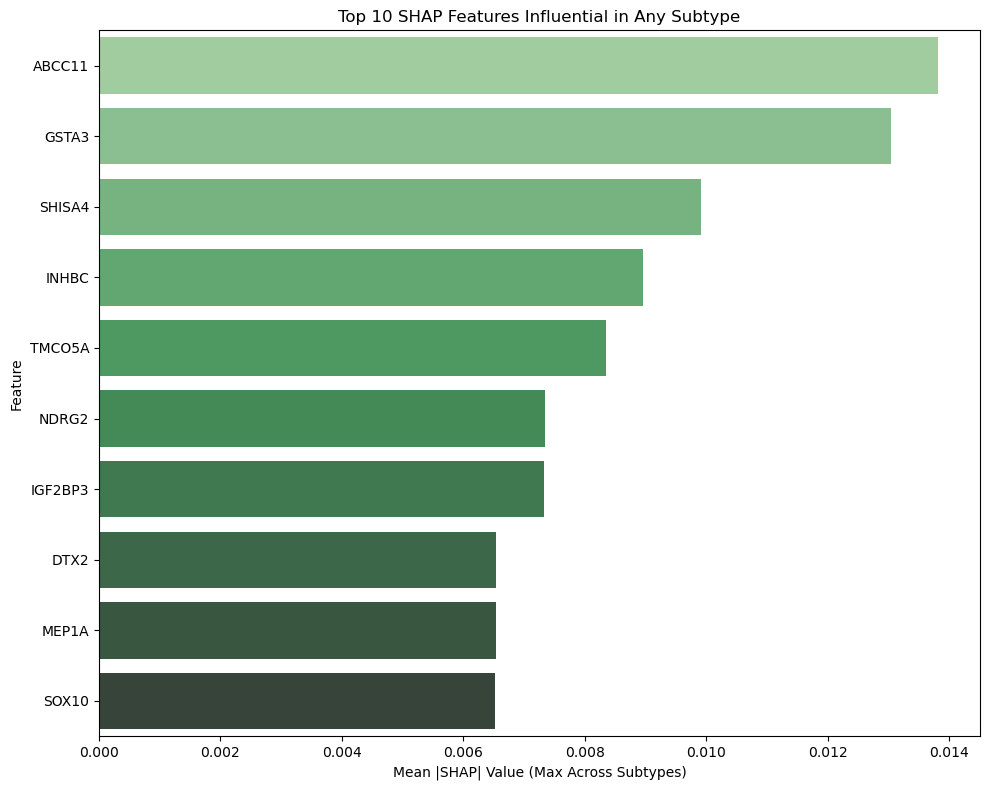

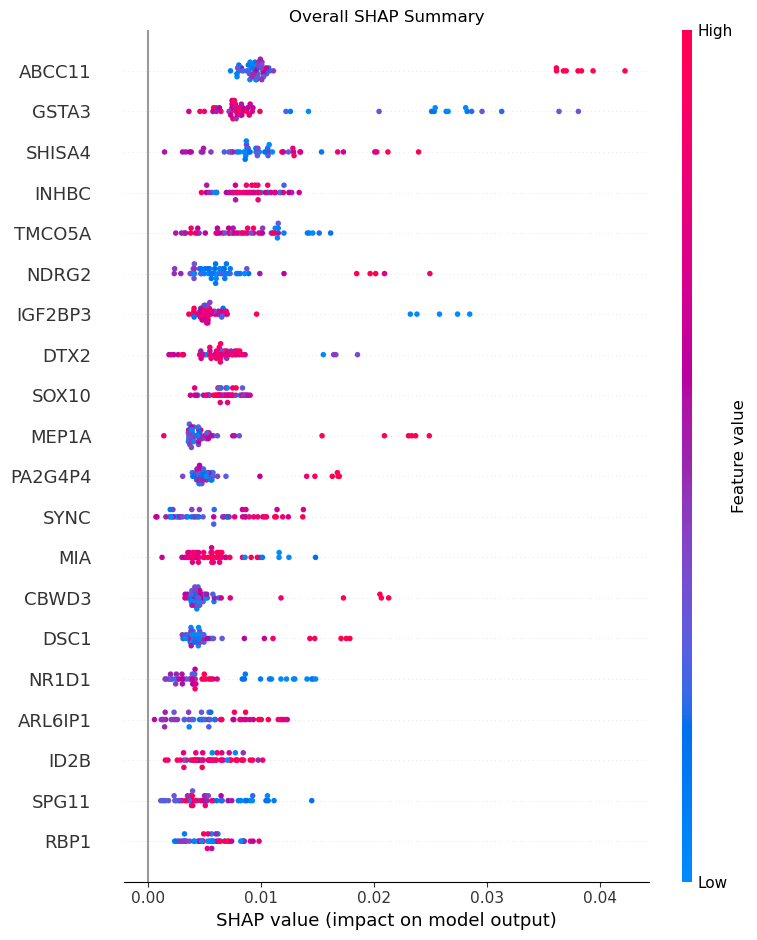


Subtype 1: Basal
       Feature  MeanAbsSHAP
438     ABCC11     0.013815
13     IGF2BP3     0.007335
143      MEP1A     0.006530
945    PA2G4P4     0.006114
235      CBWD3     0.005848
388       DSC1     0.005805
196       TNS1     0.005429
997        MIA     0.005406
137  LOC723809     0.005147
156    MIR135B     0.004842


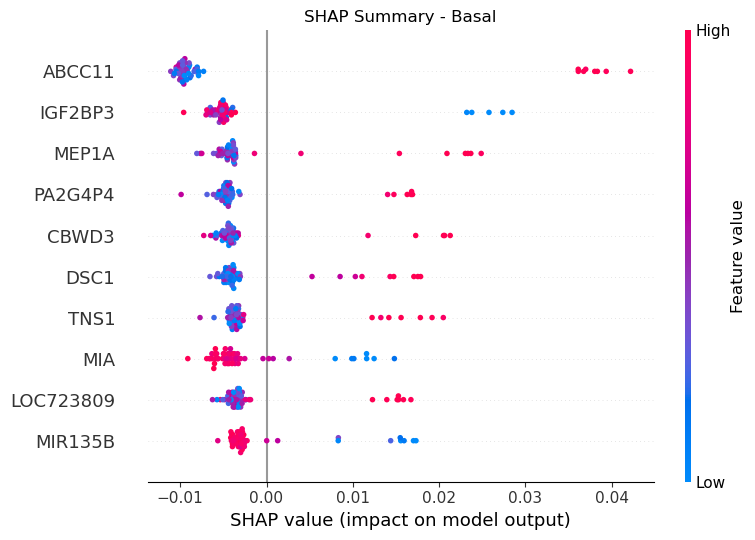

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_13028\3381405887.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


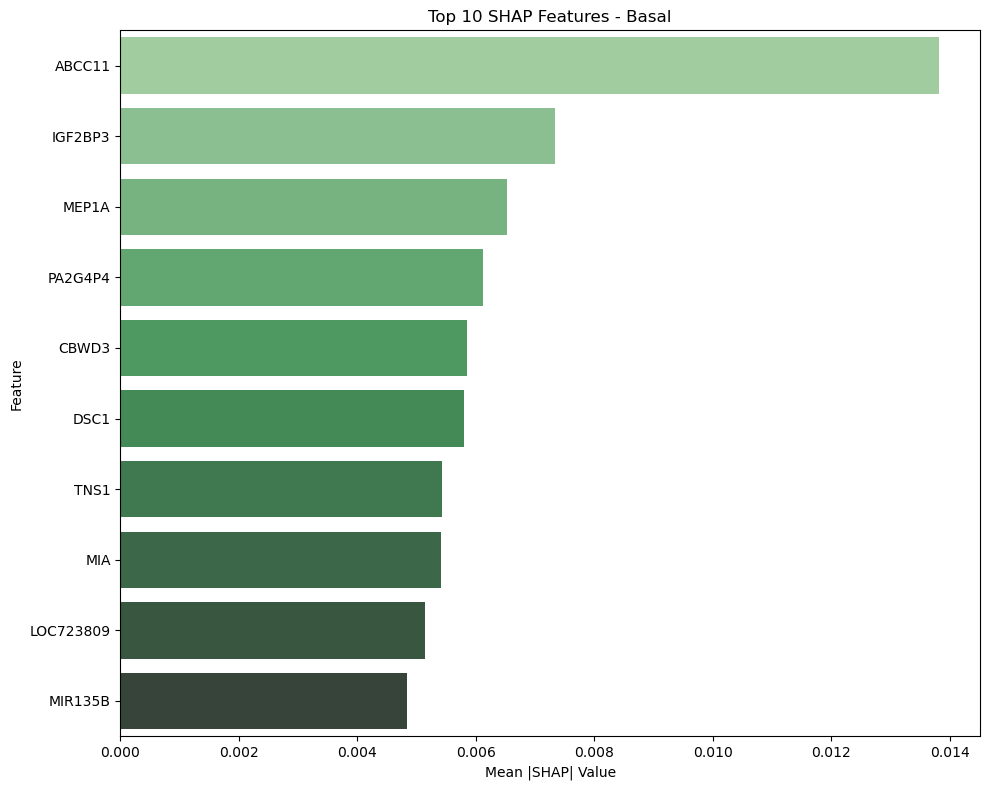


Subtype 2: Her2
     Feature  MeanAbsSHAP
426    GSTA3     0.013033
55    SHISA4     0.009917
51     NDRG2     0.007343
957     DTX2     0.006541
125    NR1D1     0.005561
784    SPG11     0.005463
524  TOMM20L     0.004708
997      MIA     0.004542
126    GSTM2     0.004537
820     MC3R     0.004525


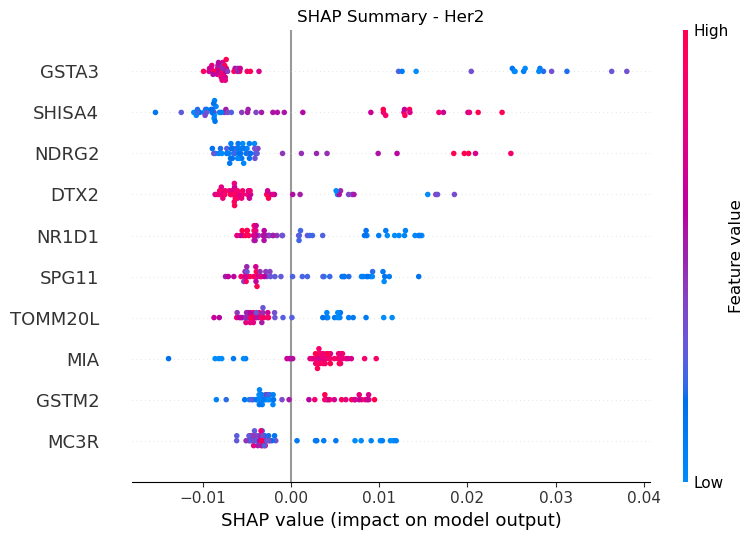

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_13028\3381405887.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


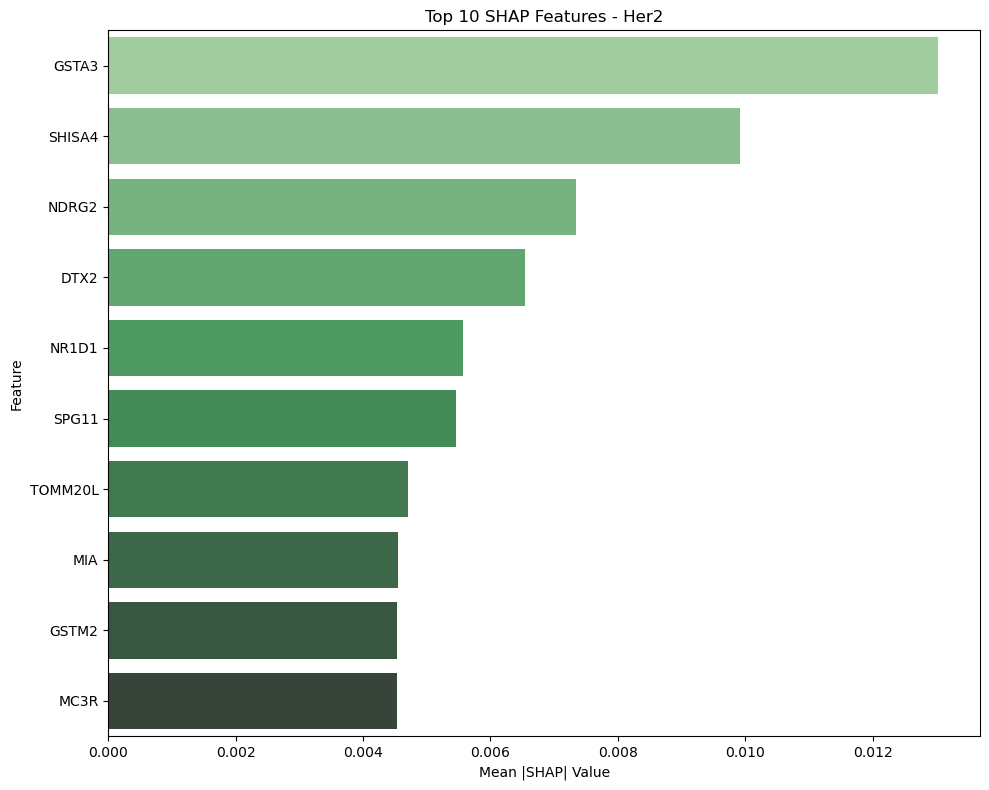


Subtype 3: LumA
     Feature  MeanAbsSHAP
426    GSTA3     0.006709
55    SHISA4     0.005510
26   ARL6IP1     0.005234
438   ABCC11     0.004610
957     DTX2     0.004329
524  TOMM20L     0.003974
210     RBP1     0.003684
13   IGF2BP3     0.003587
945  PA2G4P4     0.003213
9      BIRC5     0.003120


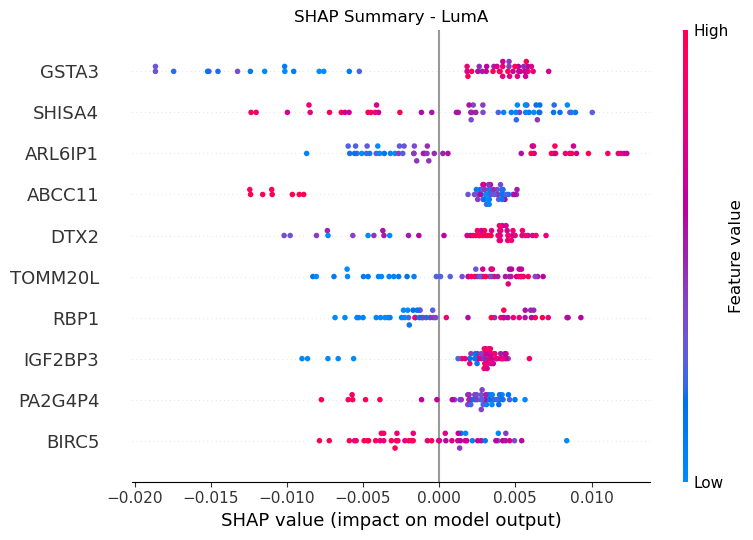

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_13028\3381405887.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


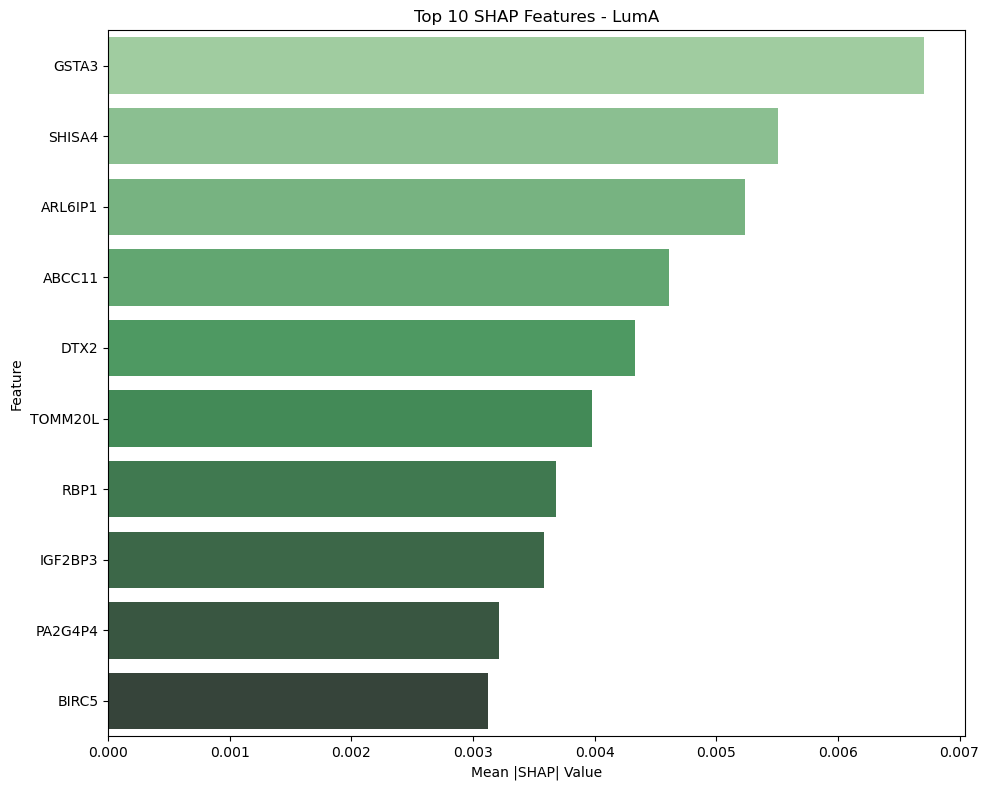


Subtype 4: LumB
    Feature  MeanAbsSHAP
345  TMCO5A     0.008355
473    SYNC     0.006130
944   INHBC     0.006028
426   GSTA3     0.004911
787    ID2B     0.004763
981   SOX10     0.004573
438  ABCC11     0.004061
9     BIRC5     0.004045
913    EPR1     0.003769
957    DTX2     0.003756


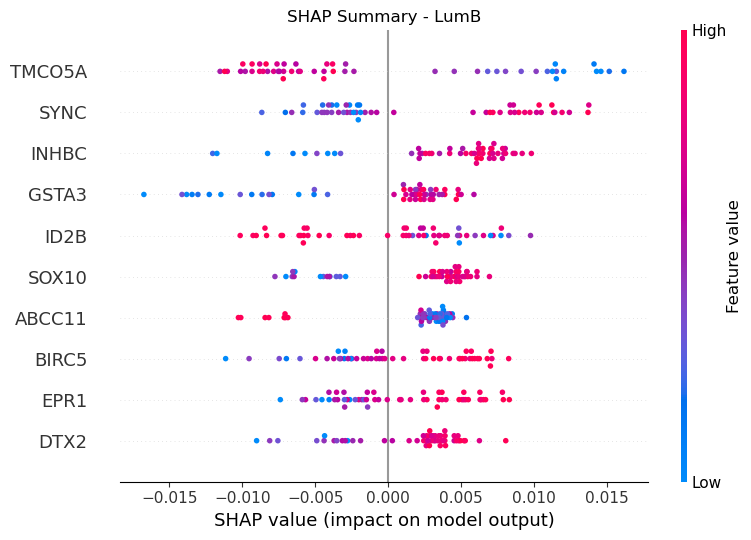

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_13028\3381405887.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


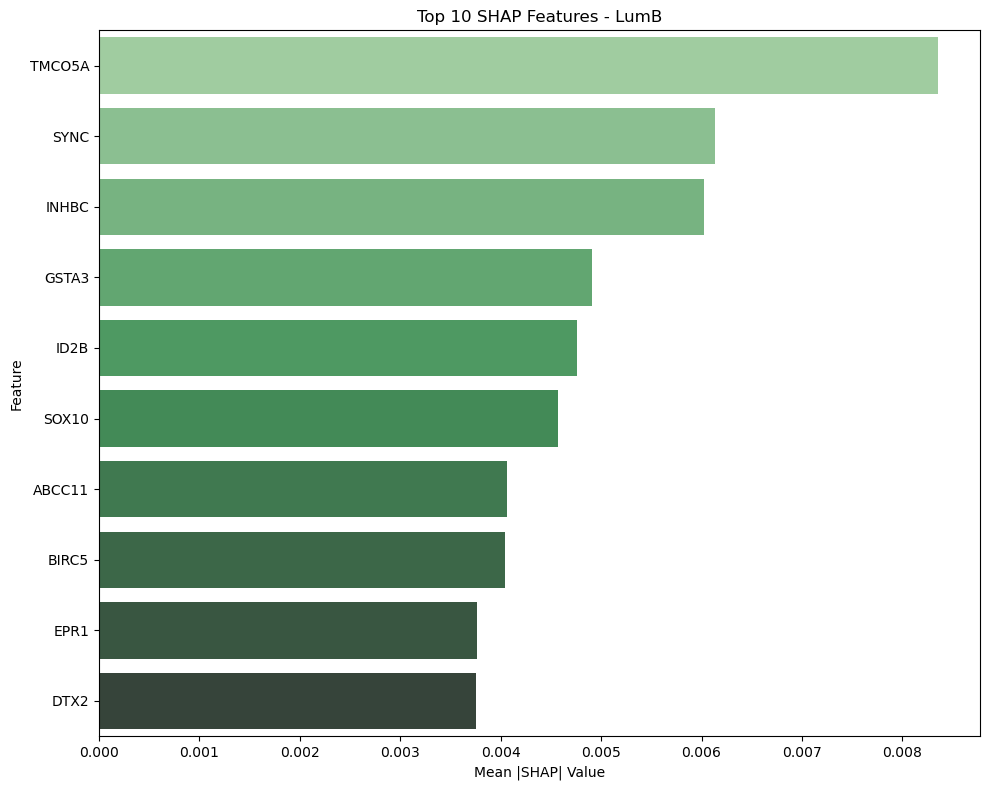


Subtype 5: Normal
        Feature  MeanAbsSHAP
944       INHBC     0.008959
981       SOX10     0.006520
55       SHISA4     0.005724
787        ID2B     0.004767
26      ARL6IP1     0.004588
63      CASKIN2     0.004539
882        MYH3     0.004116
141        PHC3     0.003786
503  NCRNA00086     0.003759
687       CASP4     0.003462


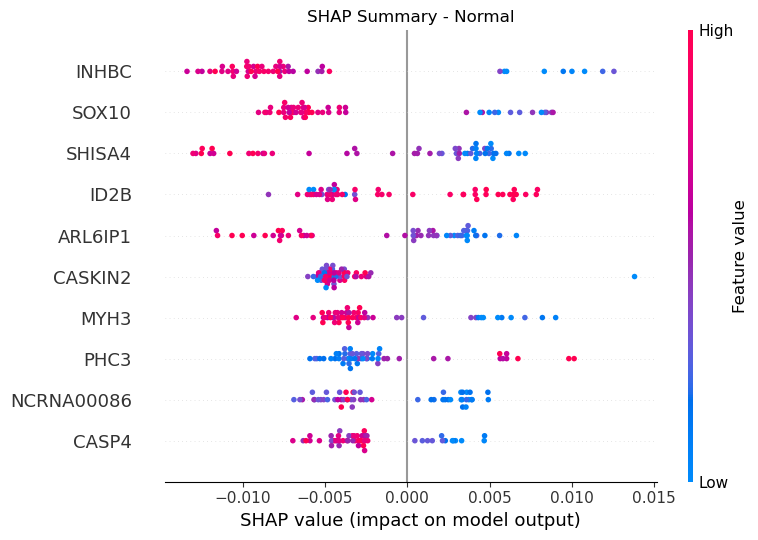

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_13028\3381405887.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


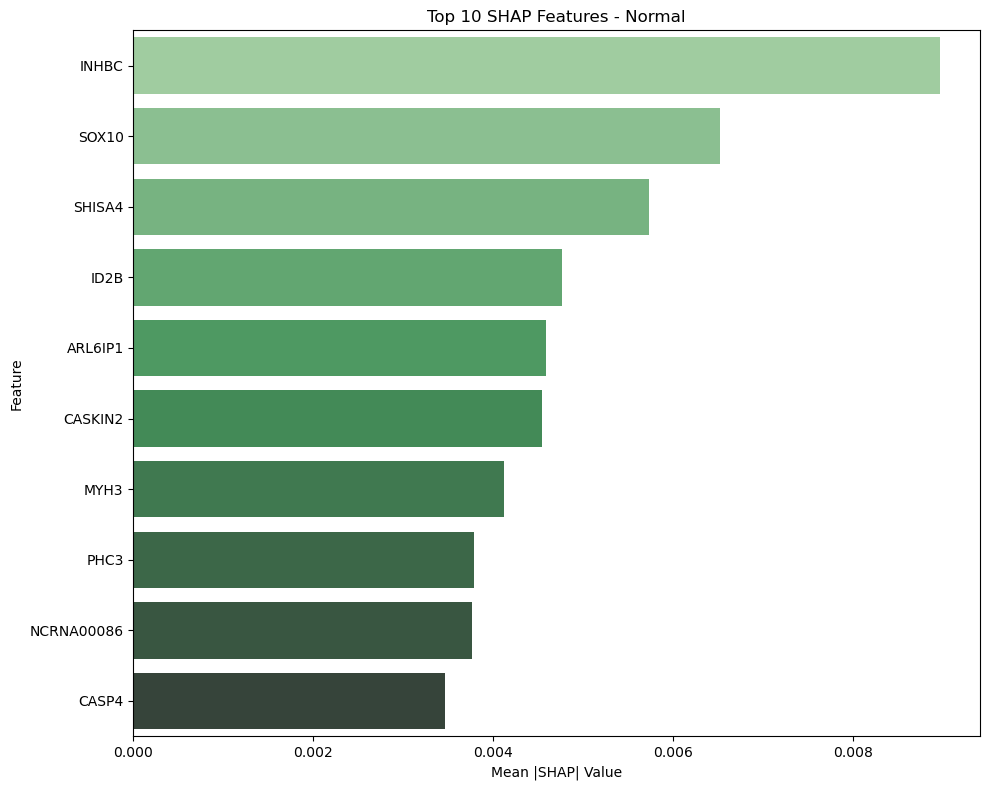


SHAP analysis complete — both overall and per-subtype results generated.


In [3]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_Norway_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

# Scale test set
X_test_scaled = scaler.transform(X_test)
X_test_selected = X_test_scaled[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")